In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt 
import seaborn as  sns

In [109]:
train=pd.read_csv("titanic_data.csv")

In [111]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [113]:
test=train.drop(columns=["Survived"])

In [115]:
test.shape

(891, 11)

In [117]:
train.shape

(891, 12)

## Data Visualisation

C:\Users\Asus\AppData\Local\Temp\ipykernel_15268\262935181.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex",y="Survived",data=train,palette={"male":"blue","female":"orange"})


<Axes: xlabel='Sex', ylabel='Survived'>

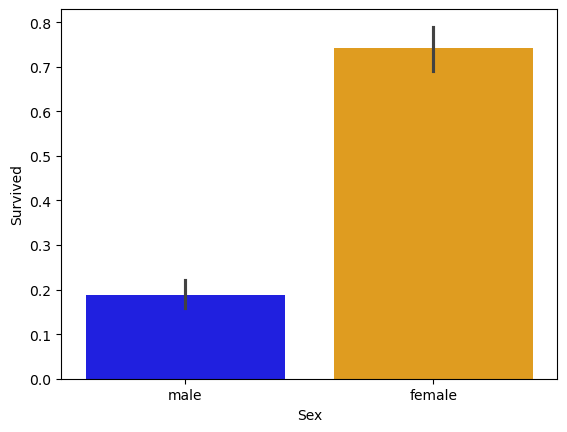

In [120]:
sns.barplot(x="Sex",y="Survived",data=train,palette={"male":"blue","female":"orange"})

### PClass

<Axes: xlabel='Pclass', ylabel='Survived'>

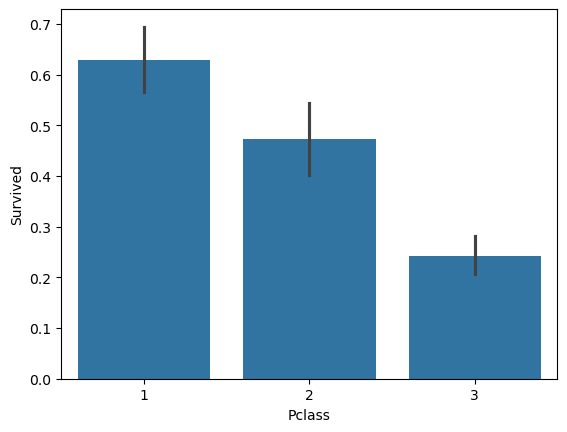

In [122]:
sns.barplot(x="Pclass",y="Survived",data=train)

## AGE

In [124]:
train["Age"]=train["Age"].fillna(-0.5)
test["Age"]=test["Age"].fillna(-0.5)

In [125]:
train["Age"].isnull().sum()

0

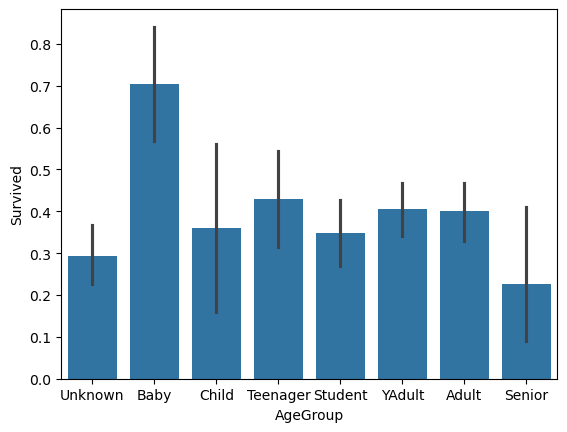

In [126]:
bins=[-1,0,5,12,18,24,35,60,np.inf]

labels=["Unknown","Baby","Child","Teenager","Student","YAdult","Adult","Senior"]

train["AgeGroup"]=pd.cut(train["Age"],bins,labels=labels)
test["AgeGroup"]=pd.cut(test["Age"],bins,labels=labels)

sns.barplot(x="AgeGroup",y="Survived",data=train)
plt.show()

In [127]:
train=train.drop(["Ticket","Cabin","Fare"],axis=1)
test=test.drop(["Ticket","Cabin","Fare"],axis=1)

## Dealing wiht Missing Values

In [129]:
print(train[train["Embarked"]=="S"].shape[0])

644


In [130]:
print(train[train["Embarked"]=="C"].shape[0])

168


In [131]:
print(train[train["Embarked"]=="Q"].shape[0])

77


In [132]:
train=train.fillna({"Embarked":"S"})

In [143]:
test=test.fillna({"Embarked":"S"})

In [145]:
combine=[train,test]

for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract( '([A-Za-z]+)\.',expand=False)

pd.crosstab(train['Title'],train["Sex"])

Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


In [51]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Embarked,AgeGroup,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,S,Student,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,C,Adult,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,S,YAdult,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,S,YAdult,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,S,YAdult,Mr


In [153]:
for dataset in combine:
    dataset["Title"]=dataset["Title"].replace(["Lady","Capt","Col","Don","Dr","Major",
                                              "Rev","Jonkheer","Dona"],"Rare")
    dataset["Title"]=dataset["Title"].replace(["Countess","Lady","Sir"],"Royal")
    dataset["Title"]=dataset["Title"].replace("Mlle","Miss")
    dataset["Title"]=dataset["Title"].replace("Ms","Miss")
    dataset["Title"]=dataset["Title"].replace("Mme","Mrs")

In [155]:
train[["Title","Survived"]].groupby(["Title"],as_index=True).mean()

,Survived
Title,
Master,0.575000
Miss,0.702703
Mr,0.156673
Mrs,0.793651
Rare,0.285714
Royal,1.000000


In [167]:
train["Title"].value_counts().get("Mrs",0)

0

In [169]:
train["AgeGroup"].unique()

['Student', 'Adult', 'YAdult', 'Unknown', 'Baby', 'Teenager', 'Child', 'Senior']
Categories (8, object): ['Unknown' < 'Baby' < 'Child' < 'Teenager' < 'Student' < 'YAdult' < 'Adult' < 'Senior']

In [161]:
title_mapping={'Mr':1,"Mrs":2,"Miss":3,"Master":4,"Rare":6,"Royal":5}

for dataset in combine:
    dataset["Title"]=dataset["Title"].map(title_mapping)
    dataset["Title"]=dataset["Title"].fillna(0)

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Embarked,AgeGroup,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,S,Student,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,C,Adult,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,S,YAdult,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,S,YAdult,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,S,YAdult,1


In [173]:
mr_age=train[train["Title"]==1]["AgeGroup"].mode()  #Yadult
miss_age=train[train["Title"]==2]["AgeGroup"].mode() #Adult
mrs_age=train[train["Title"]==3]["AgeGroup"].mode() #Unknown
master_age=train[train["Title"]==4]["AgeGroup"].mode() #Baby
royal_age=train[train["Title"]==5]["AgeGroup"].mode() #YAdult
rare_age=train[train["Title"]==6]["AgeGroup"].mode() # Adult

In [175]:
print(mr_age,miss_age,mrs_age,master_age,royal_age,rare_age)

0    YAdult
Name: AgeGroup, dtype: category
Categories (8, object): ['Unknown' < 'Baby' < 'Child' < 'Teenager' < 'Student' < 'YAdult' < 'Adult' < 'Senior'] 0    Adult
Name: AgeGroup, dtype: category
Categories (8, object): ['Unknown' < 'Baby' < 'Child' < 'Teenager' < 'Student' < 'YAdult' < 'Adult' < 'Senior'] 0    Unknown
Name: AgeGroup, dtype: category
Categories (8, object): ['Unknown' < 'Baby' < 'Child' < 'Teenager' < 'Student' < 'YAdult' < 'Adult' < 'Senior'] 0    Baby
Name: AgeGroup, dtype: category
Categories (8, object): ['Unknown' < 'Baby' < 'Child' < 'Teenager' < 'Student' < 'YAdult' < 'Adult' < 'Senior'] 0    YAdult
1     Adult
Name: AgeGroup, dtype: category
Categories (8, object): ['Unknown' < 'Baby' < 'Child' < 'Teenager' < 'Student' < 'YAdult' < 'Adult' < 'Senior'] 0    Adult
Name: AgeGroup, dtype: category
Categories (8, object): ['Unknown' < 'Baby' < 'Child' < 'Teenager' < 'Student' < 'YAdult' < 'Adult' < 'Senior']


In [179]:
age_title_map={1:"YAdult",2:"Adult",3:"Unknown",4:"Baby",5:"YAdult",6:"Adult"}

for i in range(len(train["AgeGroup"])):
    if train["AgeGroup"][i]=="Unknown":
        train["AgeGroup"][i]=age_title_map[train["Title"][i]]

for i in range(len(test["AgeGroup"])):
    if test["AgeGroup"][i]=="Unknown":
        test["AgeGroup"][i]=age_title_map[test ["Title"][i]]

In [183]:
train.AgeGroup.unique()

['Student', 'Adult', 'YAdult', 'Baby', 'Teenager', 'Child', 'Unknown', 'Senior']
Categories (8, object): ['Unknown' < 'Baby' < 'Child' < 'Teenager' < 'Student' < 'YAdult' < 'Adult' < 'Senior']

In [185]:
from sklearn.preprocessing import LabelEncoder
transform=["Sex","AgeGroup","Embarked"]

le=LabelEncoder()

for i in transform:
    train[i]=le.fit_transform(train[i])

In [191]:
for i in transform:
    test[i]=le.fit_transform(test[i])

In [193]:
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Embarked,AgeGroup,Title
0,1,3,"Braund, Mr. Owen Harris",1,22.0,1,0,2,4,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,0,0,2
2,3,3,"Heikkinen, Miss. Laina",0,26.0,0,0,2,7,3
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,2,7,2
4,5,3,"Allen, Mr. William Henry",1,35.0,0,0,2,7,1
...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",1,27.0,0,0,2,7,6
887,888,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,2,4,3
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,-0.5,1,2,2,6,3
889,890,1,"Behr, Mr. Karl Howell",1,26.0,0,0,0,7,1


In [197]:
x_train=train.drop(["PassengerId","Name","Survived"],axis=1)
y_train=train["Survived"]

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_train,y_train,test_size=0.3)

In [201]:
x_train.shape

(623, 8)

In [203]:
x_test.shape

(268, 8)

In [205]:
y_train.shape

(623,)

In [211]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()

lr.fit(x_train,y_train)

pred=lr.predict(x_test)

In [225]:
count = 0
for i1, i2 in zip(y_test, pred):
    if i1 != i2:
        count += 1

count

46